In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250718-naturalness-training-tuning',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'HSP82_YEAST_Flynn_2019', 'HXK4_HUMAN_Gersing_2022_activity', 'PPM1D_HUMAN_Miller_2022', 'CBS_HUMAN_Sun_2020', 'SHOC2_HUMAN_Kwon_2022', 'BLAT_ECOLX_Firnberg_2014', 'ANCSZ_Hobbs_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'OXDA_RHOTO_Vanella_2023_activity'}


In [3]:
round_metrics_df.config_name.unique()

array(['FolDE-hotstart-20epochs', 'FolDE-hotstart-100epochs',
       'FolDE-hotstart-10epochs', 'FolDE-hotstart-1epochs',
       'FolDE-hotstart-200epochs', 'FolDE-hotstart-0epochs',
       'FolDE-hotstart-5epochs', 'FolDE-hotstart-50epochs'], dtype=object)

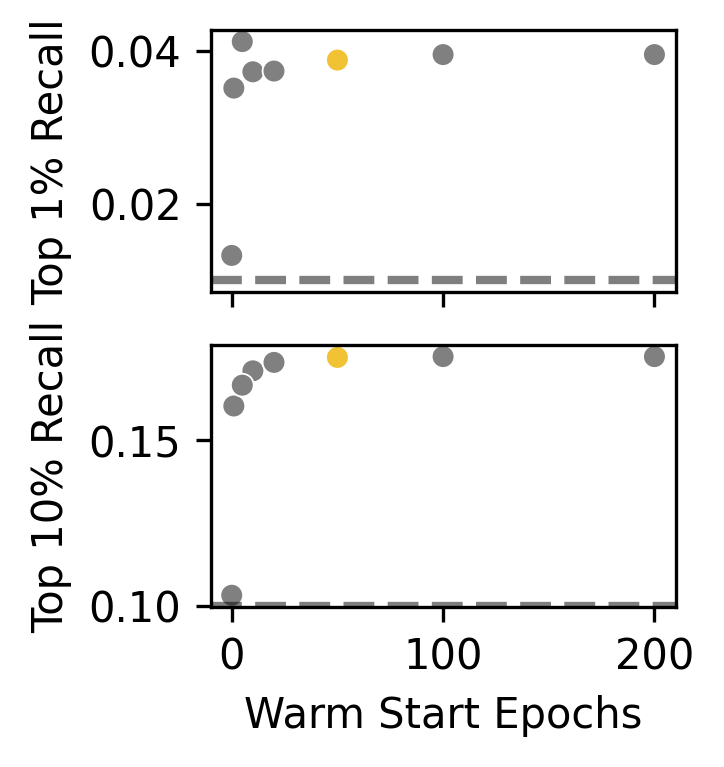

In [ ]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2, 2.5), sharex=True, dpi=300)

PLOT_TYPE = 'scatter'
ROUND = 2
# PLOT_TYPE = 'bar'
# PLOT_TYPE = 'boxplot'

config_name_list = [
    # ('FolDE-base', 'base'),
    ('FolDE-hotstart-0epochs', '0 Rounds'),
    ('FolDE-hotstart-1epochs', '1 Rounds'),
    ('FolDE-hotstart-5epochs', '5 Rounds'),
    ('FolDE-hotstart-10epochs', '10 Rounds'),
    ('FolDE-hotstart-20epochs', '20 Rounds'),
    ('FolDE-hotstart-50epochs', '50 Rounds'),
    ('FolDE-hotstart-100epochs', '100 Rounds'),
    ('FolDE-hotstart-200epochs', '200 Rounds'),
]

config_name_map = {k: v for k, v in config_name_list}
initial_metrics_df = round_metrics_df[round_metrics_df.round_num == ROUND].copy()
initial_metrics_df = initial_metrics_df[initial_metrics_df.config_name.isin([c[0] for c in config_name_list])]

initial_metrics_df['model_name'] = initial_metrics_df.config_name.apply(lambda x: config_name_map[x])
initial_metrics_df['Warm Start Epochs'] = initial_metrics_df.model_name.apply(lambda x: int(x.split(' ')[0]))


for ii, (ax, metric) in enumerate(zip([ax1, ax2], ['held_out_1pct_recall', 'held_out_10pct_recall'])):
    grouped_df = initial_metrics_df.groupby(['model_name', 'round_num', 'Warm Start Epochs'])[metric].mean().reset_index()
    def get_color(model_name):
        if model_name == '50 Rounds':
            return '#F1C233'
        else:
            return 'grey'
    if PLOT_TYPE == 'scatter':
        sns.scatterplot(
            data=grouped_df,
            hue='model_name',
            x='Warm Start Epochs',
            y=metric,
            ax=ax,
            s=20,
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            legend=False,
        )
    elif PLOT_TYPE == 'bar':
        sns.barplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in config_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            ax=ax,
        )
    elif PLOT_TYPE == 'boxplot':
        sns.boxplot(
            data=initial_metrics_df,
            x='model_name',
            y=metric,
            order=[c[1] for c in config_name_list],
            # hue='Model Family',
            palette={c[1]: get_color(c[1]) for c in config_name_list},
            ax=ax,
        )
    else:
        assert False, PLOT_TYPE
    # ax.set_xticklabels([int(c[1].split(' ')[0]) for c in config_name_list], rotation=45, ha='right')

    ax.axhline(
        y=0.01 if metric == 'held_out_1pct_recall' else 0.1,
        color='black',
        linestyle='--',
        linewidth=2,
        alpha=0.5,
        label='Random Baseline'
    )

    if metric == 'held_out_1pct_recall':
        ax.set_ylabel('Top 1% Recall')
    elif metric == 'held_out_10pct_recall':
        ax.set_ylabel('Top 10% Recall')
    
    # if PLOT_TYPE == 'scatter':
    #     ax.set_xticks([1e7, 1e8, 1e9, 1e10])
    # else:
    #     ax.set_xticklabels([c[1] for c in config_name_list])
    
# ax1.get_legend().remove()

if PLOT_TYPE == 'scatter':
    ax2.set_xlabel('Warm Start Epochs')
    # ax2.legend(
    #     title='Warm Sta',
    #     loc='lower right',
    #     bbox_to_anchor=(0.85, -1.8),
    #     fontsize=8
    # )
else:
    ax2.set_xlabel('Warm Start Epochs')


